In [50]:
import numpy as np
import pandas as pd
import seaborn as sns

In [51]:
data = pd.read_csv("processed_data_pilots.csv")

<Axes: xlabel='pos_imb_difference', ylabel='investment_share'>

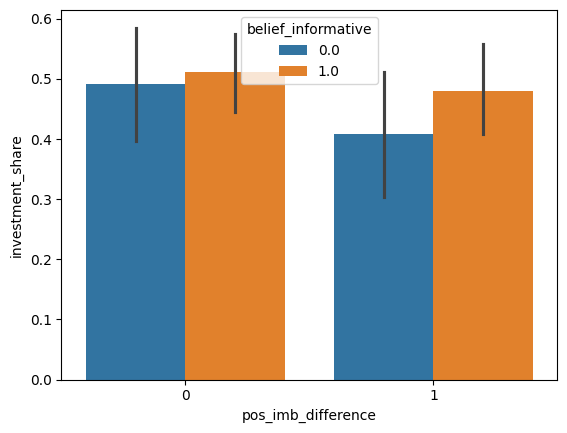

In [52]:
data['pos_imb_difference']=1*(data['imb_difference']>0)
data['pos_ret_difference']=1*(data['return_difference']>0)
sns.barplot(data=data, y='investment_share', x='pos_imb_difference', hue='belief_informative')

<Axes: xlabel='pay_for_data', ylabel='return_forecast'>

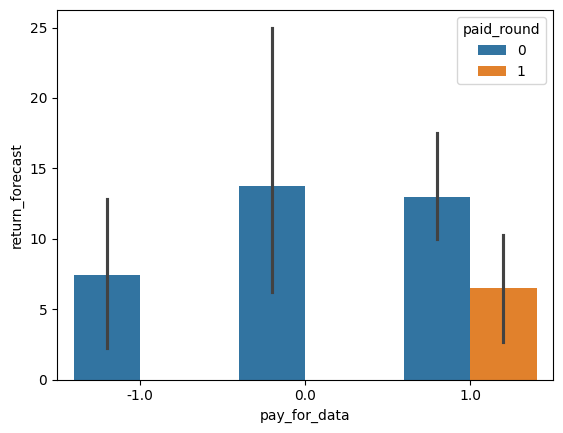

In [53]:
sns.barplot(data=data[(data.belief_informative==0) & (data.pos_imb_difference==1)], y='return_forecast', x='pay_for_data', hue='paid_round')

In [54]:
data['pos_imbalance'] = np.where(data['last_imbalance_1'] > 0, 1, 0)

<Axes: xlabel='belief_informative', ylabel='return_forecast'>

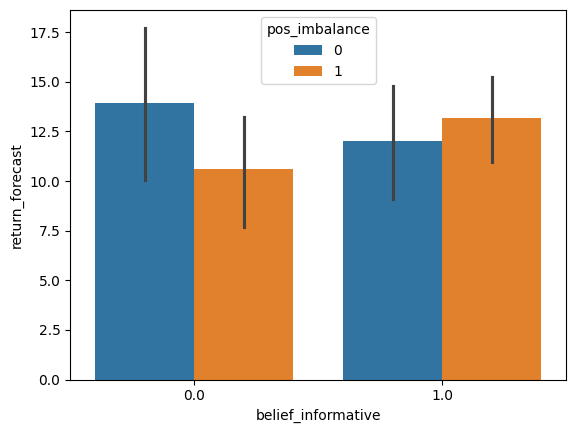

In [55]:
sns.barplot(data=data[data['data_available'] == 1], y='return_forecast', hue='pos_imbalance', x='belief_informative')

<Axes: xlabel='belief_informative', ylabel='investment_share'>

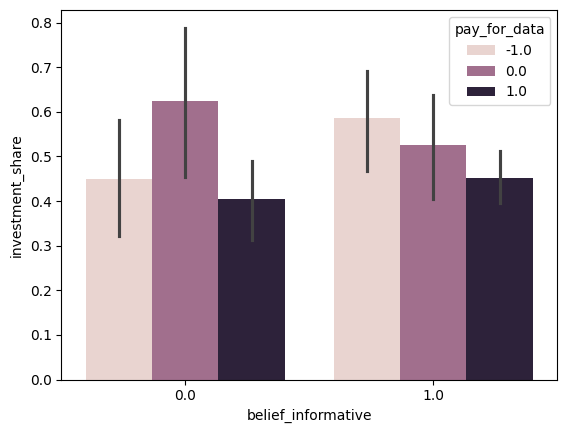

In [56]:
sns.barplot(data=data[data['data_available'] == 1], y='investment_share', hue='pay_for_data', x='belief_informative')

<Axes: xlabel='fin_quiz', ylabel='investment_share'>

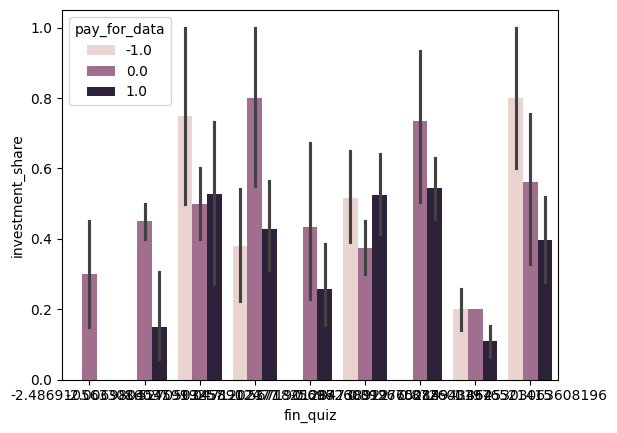

In [57]:
sns.barplot(data=data[data['data_available'] == 1], y='investment_share', x='fin_quiz', hue='pay_for_data')

In [58]:
data.groupby('treated')['paid_round'].mean()

treated
0    0.000000
1    0.666667
Name: paid_round, dtype: float64

In [59]:
data.groupby('treated')[['paid_round', 'pay_for_data']].mean()

,paid_round,pay_for_data
treated,,
0,0.000000,-1.000000
1,0.666667,0.512821


In [60]:
data['paid_dummy'] = np.where((data['paid_round'] == 1) & (data['pay_for_data'] == 1), 1, 0)

<Axes: xlabel='pay_for_data', ylabel='fin_quiz'>

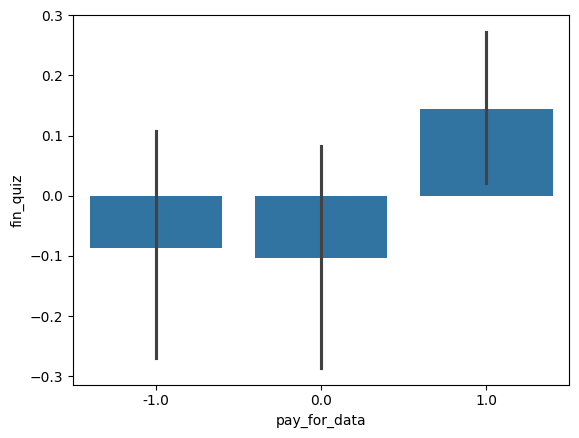

In [61]:
sns.barplot(data=data, x='pay_for_data', y='fin_quiz')

In [62]:
data[(data.treated == 1) & (data.informative == 0)].groupby('gender_female')[
    ['pay_for_data', 'investment_share', 'overconfidence', 'belief_informative']].mean()

,pay_for_data,investment_share,overconfidence,belief_informative
gender_female,,,,
0,0.561404,0.511191,0.074633,0.703704
1,0.547619,0.347256,0.024749,0.571429


In [63]:
data[(data.treated == 1) & (data.informative == 1)].groupby('gender_female')[
    ['pay_for_data', 'investment_share', 'overconfidence', 'belief_informative']].mean()

,pay_for_data,investment_share,overconfidence,belief_informative
gender_female,,,,
0,0.438596,0.466025,0.074633,0.704225
1,0.547619,0.376579,0.024749,0.838710


<Axes: xlabel='pos_imbalance', ylabel='investment_share'>

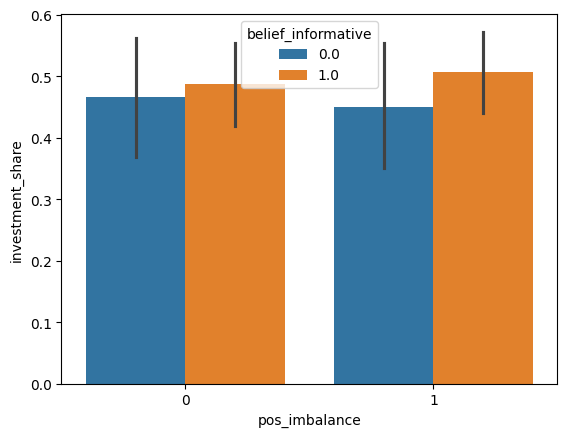

In [64]:
data['pos_forecast'] = 1 * (data['return_forecast'] > 0)
sns.barplot(data=data, x='pos_imbalance', y='investment_share',
            hue='belief_informative')

<Axes: xlabel='last_imbalance_1', ylabel='belief_informative'>

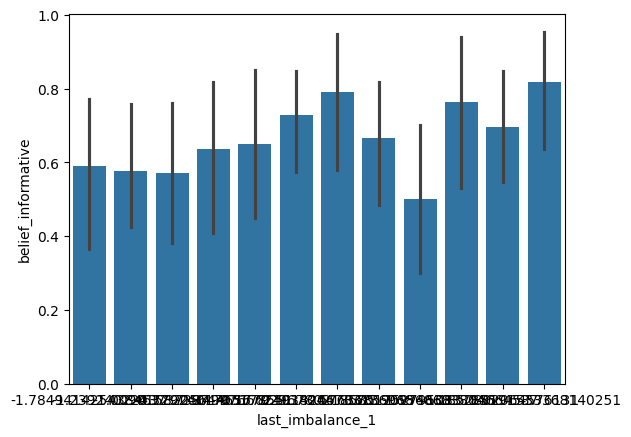

In [65]:
sns.barplot(data=data, y='belief_informative', x='last_imbalance_1')

In [66]:
data.groupby('round_number')['informative'].mean()

round_number
-1.591242    0.0
-1.301925    0.0
-1.012609    1.0
-0.723292    1.0
-0.433975    0.0
-0.144658    1.0
 0.144658    1.0
 0.433975    0.0
 0.723292    1.0
 1.012609    0.0
 1.301925    0.0
 1.591242    1.0
Name: informative, dtype: float64

<Axes: xlabel='pay_for_data', ylabel='belief_informative'>

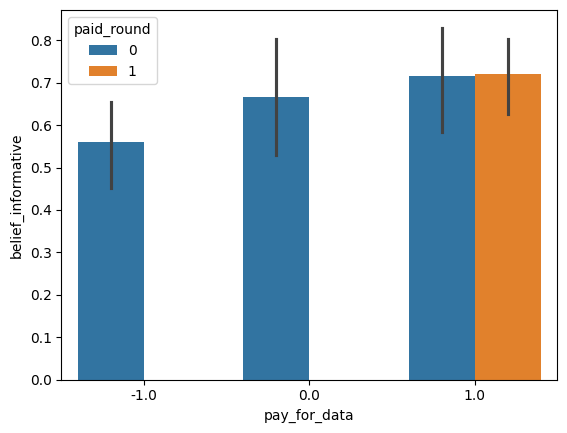

In [67]:
sns.barplot(data=data, x='pay_for_data', y='belief_informative', hue='paid_round')

<Axes: xlabel='informative', ylabel='belief_informative'>

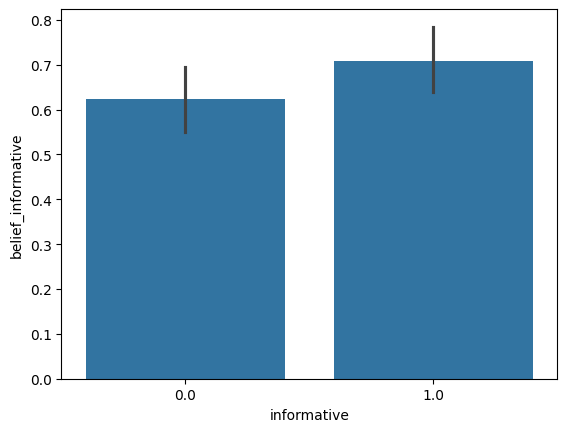

In [68]:
sns.barplot(data=data, x='informative', y='belief_informative')

In [85]:
data.groupby(['informative'])[['belief_informative']].mean()

,belief_informative
informative,
0.0,0.622517
1.0,0.708333


In [70]:
data.groupby('treated').count()

,Unnamed: 0,participant.id_in_session,participant_code,participant.label,participant._is_bot,participant._index_in_pages,participant._max_page_index,participant._current_app_name,participant._current_page_name,participant.time_started_utc,...,paid_imbalance,treated_imbalance,willing_return,paid_return,risk_aversion2,forecast_error_abs,pos_imb_difference,pos_ret_difference,pos_imbalance,pos_forecast
treated,,,,,,,,,,,,,,,,,,,,,
0,84,84,84,84,84,84,84,84,84,84,...,84,84,84,84,84,84,84,84,84,84
1,312,312,312,312,312,312,312,312,312,312,...,312,312,312,312,312,312,312,312,312,312


<Axes: xlabel='belief_informative', ylabel='return_forecast'>

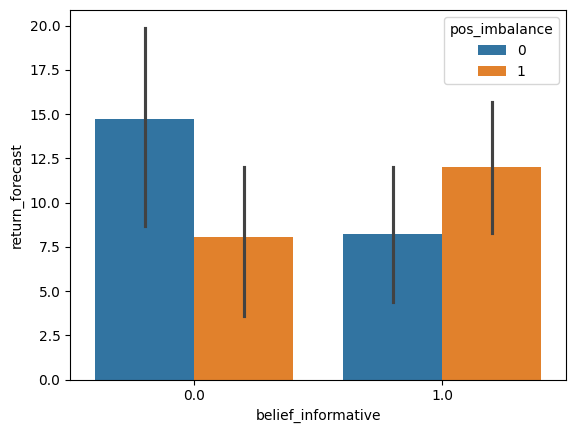

In [71]:
sns.barplot(data=data[data.paid_dummy==1], y='return_forecast', x='belief_informative',hue='pos_imbalance')

<Axes: xlabel='belief_informative', ylabel='investment_share'>

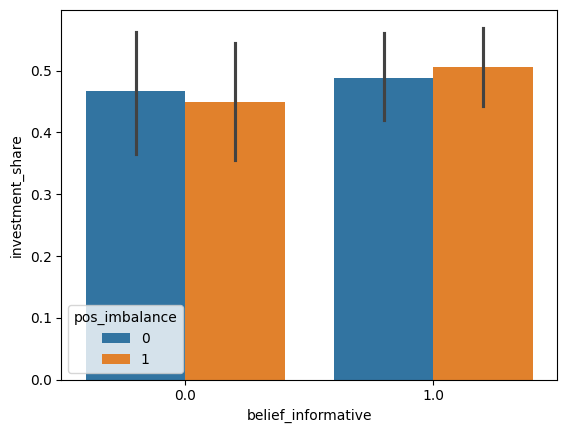

In [72]:
sns.barplot(data=data, y='investment_share', x='belief_informative',hue='pos_imbalance')

<Axes: xlabel='paid_round', ylabel='return_forecast'>

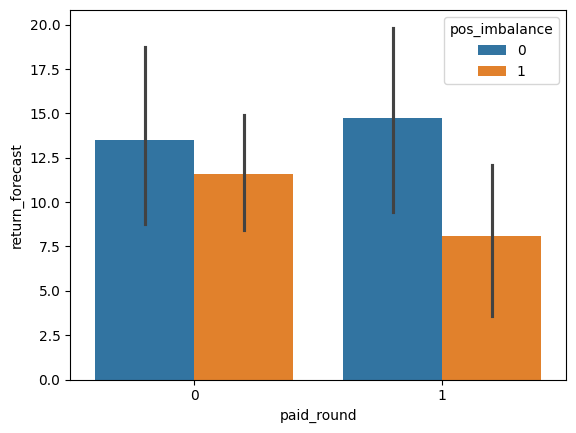

In [73]:
sns.barplot(data=data[data['belief_informative']==0], y='return_forecast', x='paid_round',hue='pos_imbalance')

<Axes: xlabel='pay_for_data', ylabel='belief_informative'>

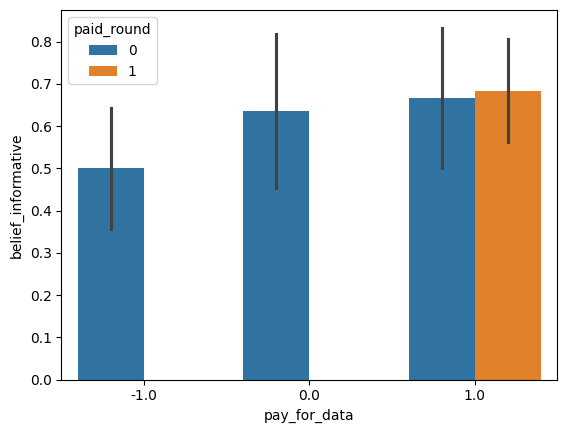

In [74]:
sns.barplot(data=data[data.informative==0], y='belief_informative', x='pay_for_data',hue='paid_round')

In [75]:
data.groupby('round_number').count()

,Unnamed: 0,participant.id_in_session,participant_code,participant.label,participant._is_bot,participant._index_in_pages,participant._max_page_index,participant._current_app_name,participant._current_page_name,participant.time_started_utc,...,paid_imbalance,treated_imbalance,willing_return,paid_return,risk_aversion2,forecast_error_abs,pos_imb_difference,pos_ret_difference,pos_imbalance,pos_forecast
round_number,,,,,,,,,,,,,,,,,,,,,
-1.591242,33,33,33,33,33,33,33,33,33,33,...,33,33,33,33,33,33,33,33,33,33
-1.301925,33,33,33,33,33,33,33,33,33,33,...,33,33,33,33,33,33,33,33,33,33
-1.012609,33,33,33,33,33,33,33,33,33,33,...,33,33,33,33,33,33,33,33,33,33
-0.723292,33,33,33,33,33,33,33,33,33,33,...,33,33,33,33,33,33,33,33,33,33
-0.433975,33,33,33,33,33,33,33,33,33,33,...,33,33,33,33,33,33,33,33,33,33
-0.144658,33,33,33,33,33,33,33,33,33,33,...,33,33,33,33,33,33,33,33,33,33
0.144658,33,33,33,33,33,33,33,33,33,33,...,33,33,33,33,33,33,33,33,33,33
0.433975,33,33,33,33,33,33,33,33,33,33,...,33,33,33,33,33,33,33,33,33,33
0.723292,33,33,33,33,33,33,33,33,33,33,...,33,33,33,33,33,33,33,33,33,33


In [76]:
data['correct_belief']=1*(data.belief_informative==data.informative)

In [77]:
data.groupby('participant_code')['correct_belief'].mean()

participant_code
0agbbz6t    0.416667
0zkzl65f    0.416667
1li97jle    0.250000
35jj3mv4    0.333333
3v5sipps    0.500000
4d34f1nl    0.500000
4pzjsb2b    0.250000
4tbjlhuv    0.666667
5uy60pw0    0.583333
6bbjn8v1    0.416667
6xawj670    0.250000
7czue3k2    0.500000
8vxh54dk    0.666667
9ioh8yjj    0.000000
cx4xx3np    0.416667
d8aqe2fa    0.166667
difxszml    0.500000
fcwg96au    0.583333
gi3vvfez    0.250000
gl7u8nio    0.333333
hlqkfw8x    0.500000
i3c60565    0.416667
i76mujh9    0.583333
iwq8bj53    0.166667
joi0mcuh    0.583333
k7sp0ynm    0.166667
miej8bbr    0.083333
nx9hs1ng    0.166667
p639azxy    0.500000
r8rvnx27    0.916667
rnucedhy    0.166667
sw8lem34    0.500000
vyd28ofr    0.500000
Name: correct_belief, dtype: float64

<Axes: xlabel='pos_imbalance', ylabel='return_forecast'>

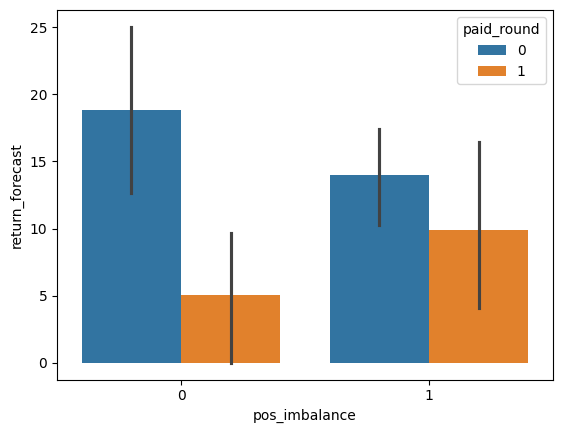

In [78]:
data['pos_imb_difference']=1*(data['imb_difference']>0)
data['pos_ret_difference']=1*(data['return_difference']>0)
sns.barplot(data=data[(data.correct_belief>=0.70) & (data.belief_informative==1)], y='return_forecast', x='pos_imbalance', hue='paid_round')

<Axes: xlabel='pos_imbalance', ylabel='return_forecast'>

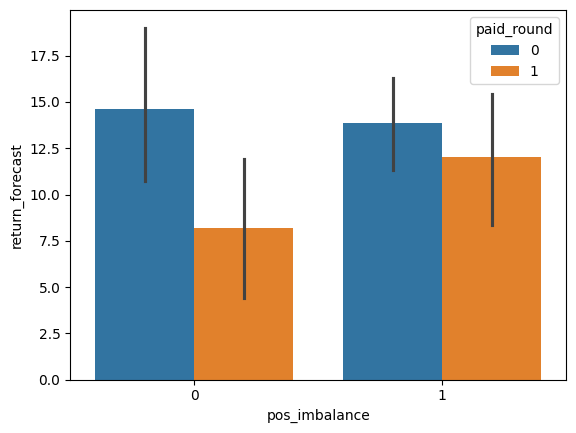

In [79]:
data['pos_imb_difference'] = 1 * (data['imb_difference'] > 0)
data['pos_ret_difference'] = 1 * (data['return_difference'] > 0)
sns.barplot(data=data[(data.belief_informative == 1)], y='return_forecast',
            x='pos_imbalance', hue='paid_round')

In [80]:
data['investment_share'].mean()

np.float64(0.4695547581073897)

In [81]:
data[data.treated==1]['pay_for_data'].mean()

np.float64(0.5128205128205128)

In [82]:
data['return_forecast'].mean()

np.float64(12.046464646464646)

In [83]:
data['investment_share'].mean()

np.float64(0.4695547581073897)

In [84]:
data['']

KeyError: ''